<a href="https://colab.research.google.com/github/dariojuri/Progetto_ML/blob/main/Progetto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Originale con valori mancanti

In [1]:
#Se serve vedere il database originale togli i commenti
#from google.colab import data_table
#data_table.enable_dataframe_formatter()
#pd.set_option('display.max_columns', None)
#df.sample(25)

Caricamento del DataBase

In [2]:
!pip install -q ucimlrepo #Installa una libreria che su Colab non c'è
# !-> comando di sistema, -q lo nasconde dal log

import pandas as pd, numpy as np #pandas per le tabelle, numpy per i calcoli numerici

import matplotlib.pyplot as plt, seaborn as sns #librerie per i grafici

from ucimlrepo import fetch_ucirepo #una sola libreria per scaricare il dataset

ds = fetch_ucirepo(id=296)       #scarica il dataset n. 296 di UCI (Diabetes 130)
#ds paccehtto completo con dati e metadati

df = ds.data.original.copy()     #prende la tabella completa, tutte le 50 colonne
df = df.replace('?', np.nan)     #trasforma i '?' in veri valori mancanti
#df varibili che contiene dataset sotto forma di DataFrame

print(df.shape)
df.head()

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Struttura del database: nome colonna, numero di missing e tipo della colonna.

In [3]:
df.info()
print(df.nunique().sort_values(ascending=False).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Analizza il target e conta le occorrenze.

readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64
Positivi: 0.112


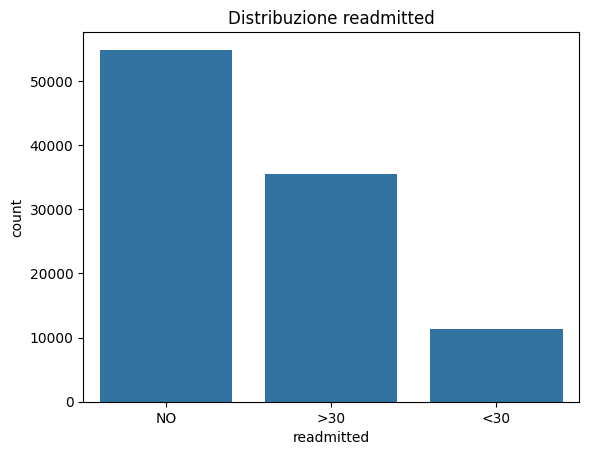

In [4]:
print(df['readmitted'].value_counts(normalize=True).round(3))
df['target'] = (df['readmitted'] == '<30').astype(int)
print('Positivi:', round(df['target'].mean(), 3))
sns.countplot(x='readmitted', data=df); plt.title('Distribuzione readmitted'); plt.show()

Conteggio dei valori mancanti

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64


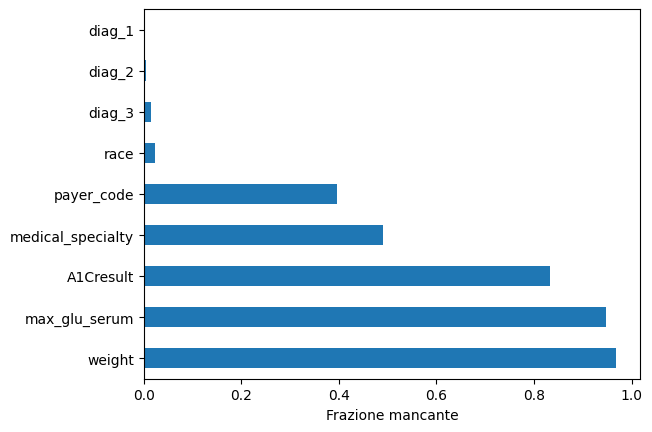

In [5]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print((miss * 100).round(1))
miss.plot.barh(); plt.xlabel('Frazione mancante'); plt.show()

Conteggio dei pazienti unici, da singolarizzare nel dataset

In [6]:
print('Ricoveri:', len(df), '| Pazienti unici:', df['patient_nbr'].nunique())
print(df['discharge_disposition_id'].value_counts().head(10))

Ricoveri: 101766 | Pazienti unici: 71518
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64


Statistiche descrittive

In [7]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses'] #Scelta delle statiche
df[num_cols].describe().round(2)   #media, dev. standard, min, quartili, max. Arrotondati

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


Distribuzioni dei dati trovati

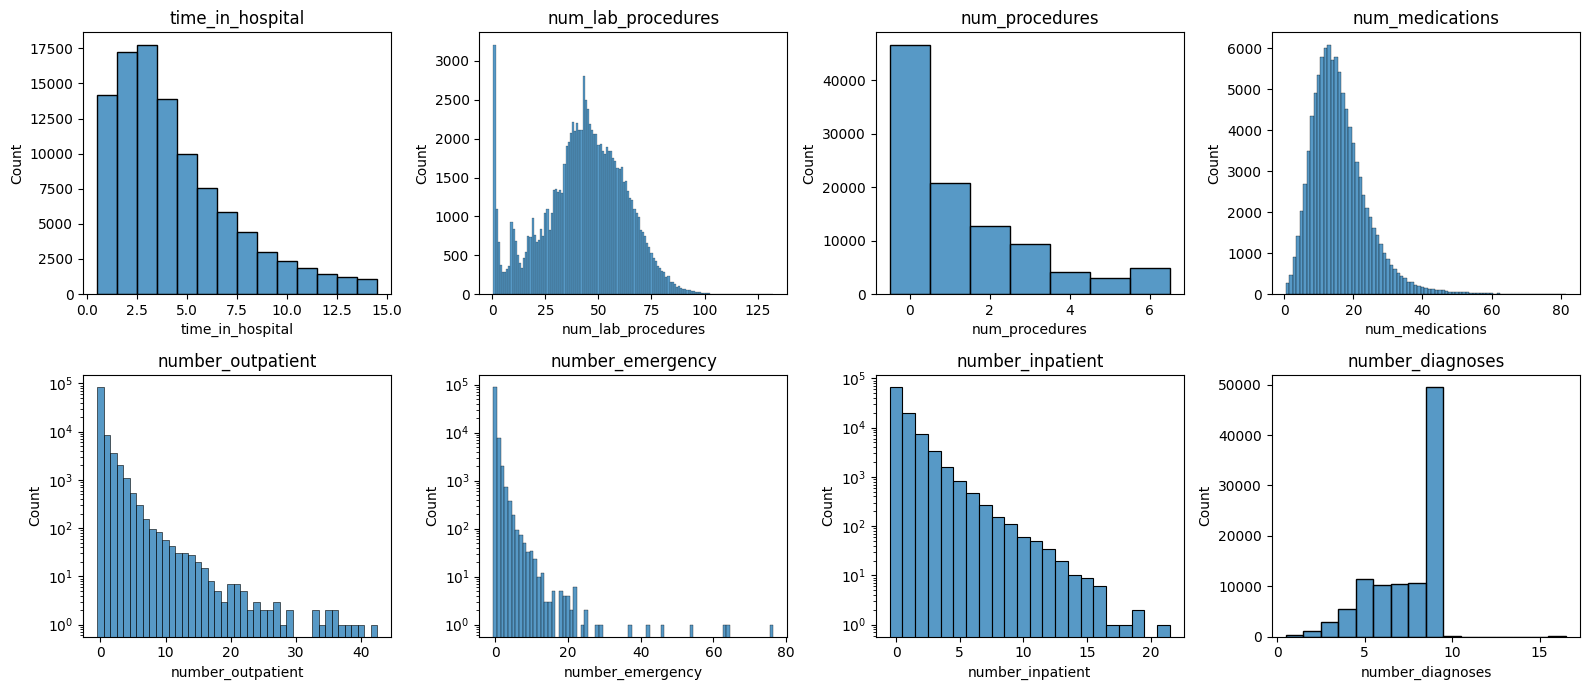

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], discrete=True, ax=ax)          # una barra per valore intero
    if col in ['number_outpatient', 'number_emergency', 'number_inpatient']:
        ax.set_yscale('log')                              # rende visibili i valori rari
    ax.set_title(col)
plt.tight_layout(); plt.show()

Outlier con il metodo IQR(Interqurtile Range).

Boxplot: la scatola va da Q1 a Q3, la linea interna è la mediana, i "baffi" arrivano a 1,5×IQR e i pallini sono gli outlier.

time_in_hospital       2.2
num_lab_procedures     0.1
num_procedures         4.9
num_medications        2.5
number_outpatient     16.4
number_emergency      11.2
number_inpatient       6.9
number_diagnoses       0.3
dtype: float64


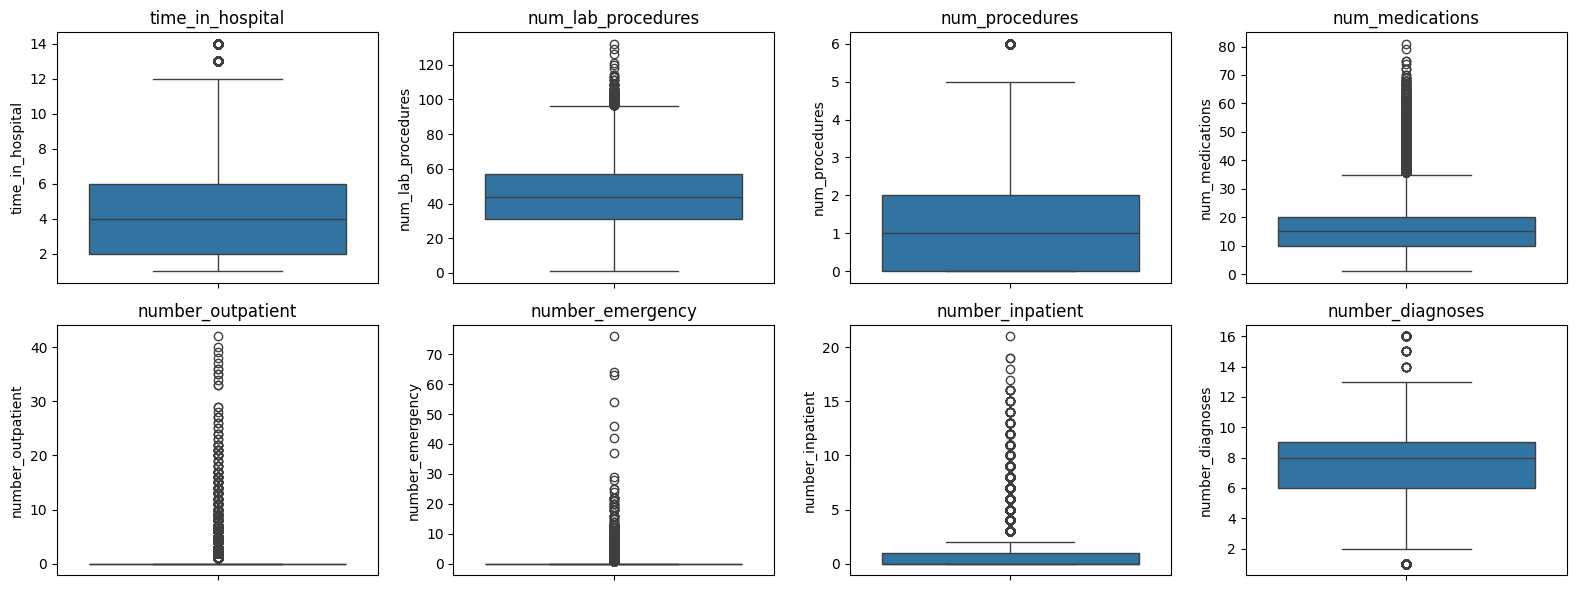

In [9]:
def perc_outlier(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1                                  #ampiezza del 50% centrale
    fuori = (s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr) #regola di Tukey(Se cade fuori questi estremi = outlier)
    return fuori.mean() * 100                      #% di valori oltre i limiti

print(df[num_cols].apply(perc_outlier).round(1))

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=df[col], ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

Relazione con il target, se le medie differiscono molto tra i gruppi, la feature aiuta a prevedere il target.


In [10]:
print(df.groupby('target')[num_cols].mean().round(2).T)   #media per classe 0(non riammessi)/1(riammessi)

tasso = df.groupby('number_inpatient')['target'].agg(['mean', 'count'])
print(tasso.head(10).round(3))   # % di riammessi per numero di ricoveri precedenti

target                  0      1
time_in_hospital     4.35   4.77
num_lab_procedures  42.95  44.23
num_procedures       1.35   1.28
num_medications     15.91  16.90
number_outpatient    0.36   0.44
number_emergency     0.18   0.36
number_inpatient     0.56   1.22
number_diagnoses     7.39   7.69
                   mean  count
number_inpatient              
0                 0.084  67630
1                 0.129  19521
2                 0.174   7566
3                 0.203   3411
4                 0.236   1622
5                 0.314    812
6                 0.346    480
7                 0.354    268
8                 0.444    151
9                 0.423    111


tradurre i codici ID nel loro significato

In [15]:
import glob
!wget -q -O diab.zip "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
!unzip -o -q diab.zip -d diab
path = glob.glob('diab/**/IDS_mapping.csv', recursive=True)[0]

mappe, corrente = {}, None
for riga in open(path):
    riga = riga.strip()
    if not riga or riga == ',':                 # salta le righe vuote
        continue
    codice, descr = riga.split(',', 1)
    if codice.endswith('_id'):                  # intestazione: inizia una nuova tabella
        corrente = codice; mappe[corrente] = {}
    else:
        mappe[corrente][int(codice)] = descr.strip('"')

for col, mappa in mappe.items():
    df[col + '_desc'] = df[col].map(mappa)      # nuova colonna con il significato
print(df[['admission_type_id', 'admission_type_id_desc']].drop_duplicates())

       admission_type_id admission_type_id_desc
0                      6                   NULL
1                      1              Emergency
5                      2                 Urgent
6                      3               Elective
2043                   4                Newborn
3089                   5          Not Available
7789                   8             Not Mapped
45829                  7          Trauma Center


funzione di analisi per categoria

In [16]:
def analisi_cat(col, top=15):
    t = df.groupby(col, dropna=False)['target'].agg(['count', 'mean'])
    t['mean'] = (t['mean'] * 100).round(1)
    t.columns = ['n_pazienti', '%_riammessi']
    return t.sort_values('n_pazienti', ascending=False).head(top)

for col in ['admission_type_id_desc', 'age', 'A1Cresult', 'max_glu_serum', 'race']:
    print(analisi_cat(col), '\n')

                        n_pazienti  %_riammessi
admission_type_id_desc                         
Emergency                    53990         11.5
Elective                     18869         10.4
Urgent                       18480         11.2
NULL                          5291         11.1
Not Available                 4785         10.3
Not Mapped                     320          8.4
Trauma Center                   21          0.0
Newborn                         10         10.0 

          n_pazienti  %_riammessi
age                              
[70-80)        26068         11.8
[60-70)        22483         11.1
[50-60)        17256          9.7
[80-90)        17197         12.1
[40-50)         9685         10.6
[30-40)         3775         11.2
[90-100)        2793         11.1
[20-30)         1657         14.2
[10-20)          691          5.8
[0-10)           161          1.9 

           n_pazienti  %_riammessi
A1Cresult                         
NaN             84748         11.4
>8 

le modalità di dimissione (la trappola)

In [17]:
print(analisi_cat('discharge_disposition_id_desc', top=30))

                                                    n_pazienti  %_riammessi
discharge_disposition_id_desc                                              
Discharged to home                                       60234          9.3
Discharged/transferred to SNF                            13954         14.7
Discharged/transferred to home with home health...       12902         12.7
NULL                                                      3691         12.4
Discharged/transferred to another short term ho...        2128         16.1
Discharged/transferred to another rehab fac inc...        1993         27.7
Expired                                                   1642          0.0
Discharged/transferred to another type of inpat...        1184         20.9
Not Mapped                                                 989          9.3
Discharged/transferred to ICF                              815         12.8
Left AMA                                                   623         14.4
Discharged/t

cardinalità delle categoriche

In [18]:
cat_cols = df.select_dtypes('object').columns           # tutte le colonne di testo
print(df[cat_cols].nunique().sort_values(ascending=False).to_string())

diag_3                           789
diag_2                           748
diag_1                           716
medical_specialty                 72
discharge_disposition_id_desc     26
admission_source_id_desc          17
payer_code                        17
age                               10
weight                             9
admission_type_id_desc             8
race                               5
insulin                            4
chlorpropamide                     4
metformin                          4
nateglinide                        4
repaglinide                        4
acarbose                           4
miglitol                           4
rosiglitazone                      4
pioglitazone                       4
glyburide-metformin                4
glimepiride                        4
glyburide                          4
glipizide                          4
gender                             3
readmitted                         3
A1Cresult                          3
m